# **QMSSGR5074 – Project 3**



###Group ID: 3  
###UNIs: jz3998,yy3648, yt2968
###Names:Joey Zhu, Yu Yan, Yichen Tao
###GitHub Repo: [Fill Here]

---
# Part 1 – Data Ingestion & Preprocessing


---



## 1.1 Environment Setup

In [ ]:
!pip install -U transformers tokenizers accelerate huggingface_hub sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 32.3 MB/s eta 0:00:00


In [ ]:
import os, re, string, pickle, random, subprocess, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
)
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Environment ready.")

Environment ready.


## 1.2 Data Loading

We use the **Stanford Sentiment Treebank (SST-2)** dataset — a standard benchmark for binary sentiment classification consisting of movie-review phrases labeled as **positive (1)** or **negative (0)**.

We clone the publicly available dataset repository and load the labeled train and development splits. Since the official test split has no labels, we build our own stratified partitions from the labeled data.

In [ ]:
DATA_DIR = "SST-2-sentiment-analysis/data"
if not os.path.exists(DATA_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/YJiangcm/SST-2-sentiment-analysis.git"],
        check=True
    )

# Each file: label \t sentence, no header
train_raw = pd.read_csv(f"{DATA_DIR}/train.tsv", sep="\t", header=None, names=["label", "sentence"])
dev_raw   = pd.read_csv(f"{DATA_DIR}/dev.tsv",   sep="\t", header=None, names=["label", "sentence"])

full_df = pd.concat([train_raw, dev_raw], ignore_index=True)
full_df["label"] = full_df["label"].astype(int)

print(f"Total labeled samples : {len(full_df):,}")
print(full_df["label"].value_counts())
full_df.head()

Total labeled samples : 7,792
label
1    4054
0    3738
Name: count, dtype: int64


,label,sentence
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


### 1.2.1 Stratified Train / Validation / Test Split

**Strategy:** Two-stage stratified split preserving the class balance (~52% positive, ~48% negative) at every stage.

| Stage | Held-out proportion |
|---|---|
| Stage 1: Reserve test set | 15% of full data |
| Stage 2: Reserve validation set | 15% of remaining data |

In [ ]:
X, y = full_df["sentence"], full_df["label"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp
)

train_df = pd.DataFrame({"sentence": X_train.values, "label": y_train.values})
val_df   = pd.DataFrame({"sentence": X_val.values,   "label": y_val.values})
test_df  = pd.DataFrame({"sentence": X_test.values,  "label": y_test.values})

print(f"Training set   : {len(train_df):,} samples")
print(f"Validation set : {len(val_df):,} samples")
print(f"Test set       : {len(test_df):,} samples")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s} → {df['label'].mean()*100:.1f}% positive")

Training set   : 5,629 samples
Validation set : 994 samples
Test set       : 1,169 samples
  Train → 52.0% positive
  Val   → 52.0% positive
  Test  → 52.0% positive


## 1.3 Text Cleaning & Tokenization

We implement a reusable `TextPreprocessor` class that handles the full cleaning and tokenization pipeline without any external deep learning dependencies:

| Step | Action |
|---|---|
| HTML removal | Strip `<tag>` patterns |
| Lowercasing | Normalize casing |
| Punctuation stripping | Remove via `string.punctuation` |
| Whitespace normalization | Collapse to single spaces |
| Vocabulary pruning | Drop tokens with frequency < `min_freq` |
| Integer encoding | Map tokens to rank-ordered indices |
| Padding / truncation | Pad or truncate to fixed `max_len` |

The class is **fit only on training data** (no leakage) and is `pickle`-serializable for inference.

In [ ]:
class TextPreprocessor:
    """
    End-to-end text preprocessing pipeline.
    No TensorFlow/Keras dependency — pure Python + NumPy.

    Attributes
    ----------
    PAD : int  Padding index (0)
    OOV : int  Out-of-vocabulary index (1)
    """
    PAD = 0
    OOV = 1

    def __init__(self, max_vocab: int = 10_000, min_freq: int = 2, max_len: int = 100):
        self.max_vocab = max_vocab
        self.min_freq  = min_freq
        self.max_len   = max_len
        self.vocab_    = set()
        self.word2idx_ = {}

    def _clean(self, text: str) -> str:
        text = str(text)
        text = re.sub(r"<[^>]+>", " ", text)
        text = text.lower()
        text = text.translate(str.maketrans("", "", string.punctuation))
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def fit(self, texts):
        cleaned = [self._clean(t) for t in texts]
        counter = Counter(w for doc in cleaned for w in doc.split())
        self.vocab_ = {w for w, c in counter.items() if c >= self.min_freq}
        top_words = sorted(
            [(w, c) for w, c in counter.items() if w in self.vocab_],
            key=lambda x: -x[1]
        )[: self.max_vocab - 2]
        self.word2idx_ = {w: i + 2 for i, (w, _) in enumerate(top_words)}
        return self

    def transform(self, texts) -> np.ndarray:
        out = np.zeros((len(texts), self.max_len), dtype=np.int32)
        for i, text in enumerate(texts):
            words = [w for w in self._clean(text).split() if w in self.vocab_]
            seq   = [self.word2idx_.get(w, self.OOV) for w in words]
            l = min(len(seq), self.max_len)
            out[i, :l] = seq[:l]
        return out

    def fit_transform(self, texts) -> np.ndarray:
        return self.fit(texts).transform(texts)

    def clean_text(self, text: str) -> str:
        """Public alias for the cleaning step — used in EDA."""
        return self._clean(text)

print("TextPreprocessor defined (pure Python / NumPy).")

TextPreprocessor defined (pure Python / NumPy).


In [ ]:
# Fit ONLY on training data to prevent data leakage
preprocessor = TextPreprocessor(max_vocab=10_000, min_freq=2, max_len=100)

X_train_seq = preprocessor.fit_transform(train_df["sentence"])
X_val_seq   = preprocessor.transform(val_df["sentence"])
X_test_seq  = preprocessor.transform(test_df["sentence"])

y_train_arr = train_df["label"].values
y_val_arr   = val_df["label"].values
y_test_arr  = test_df["label"].values

print(f"Vocabulary size after pruning : {len(preprocessor.vocab_):,} unique tokens")
print(f"Tokens indexed (capped)       : {len(preprocessor.word2idx_):,}")
print(f"Sequence shapes → train: {X_train_seq.shape}, val: {X_val_seq.shape}, test: {X_test_seq.shape}")

Vocabulary size after pruning : 6,143 unique tokens
Tokens indexed (capped)       : 6,143
Sequence shapes → train: (5629, 100), val: (994, 100), test: (1169, 100)


In [ ]:
# Preview: raw → cleaned → encoded
sample = train_df["sentence"].iloc[5]
print("Original :", sample)
print("Cleaned  :", preprocessor.clean_text(sample))
print("Encoded  :", X_train_seq[5, :20], "...")

Original : funny in a sick , twisted sort of way .
Cleaned  : funny in a sick twisted sort of way
Encoded  : [  66   11    3 1274 1943  370    5   77    0    0    0    0    0    0
    0    0    0    0    0    0] ...


In [ ]:
# Save and verify reload
with open("text_preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

with open("text_preprocessor.pkl", "rb") as f:
    loaded_prep = pickle.load(f)

demo = loaded_prep.transform(["This film was absolutely wonderful and deeply moving."])
print("Preprocessor saved and reloaded successfully.")
print("Demo sequence (first 15 tokens):", demo[0, :15])

Preprocessor saved and reloaded successfully.
Demo sequence (first 15 tokens): [ 16  13  96 670 556   4 537 255   0   0   0   0   0   0   0]


## 1.4 Feature Extraction

Two feature representations are built:

| Type | Method | Used by |
|---|---|---|
| **Traditional** | TF-IDF with unigrams + bigrams (15k features) | Logistic Regression, SVM, RF, XGBoost |
| **Neural** | Padded integer sequences | Embedding layers, RNNs, CNNs (Parts 4+) |

In [ ]:
# Add cleaned text columns
for df in [train_df, val_df, test_df]:
    df["clean_sentence"] = df["sentence"].apply(preprocessor.clean_text)

tfidf = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train_df["clean_sentence"])
X_val_tfidf   = tfidf.transform(val_df["clean_sentence"])
X_test_tfidf  = tfidf.transform(test_df["clean_sentence"])

print("TF-IDF shapes:")
print(f"  Train: {X_train_tfidf.shape} | Val: {X_val_tfidf.shape} | Test: {X_test_tfidf.shape}")

TF-IDF shapes:
  Train: (5629, 14751) | Val: (994, 14751) | Test: (1169, 14751)


In [ ]:
# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("tfidf_vectorizer.pkl", "rb") as f:
    loaded_tfidf = pickle.load(f)

check = loaded_tfidf.transform(["this film was surprisingly funny and emotionally powerful"])
print(f"TF-IDF vectorizer saved and reloaded. Shape check: {check.shape}")

TF-IDF vectorizer saved and reloaded. Shape check: (1, 14751)


---
# Part 2 – Exploratory Data Analysis (EDA)


---



## 2.1 Class Distribution

We examine the class balance and compute descriptive statistics on review length (word count).

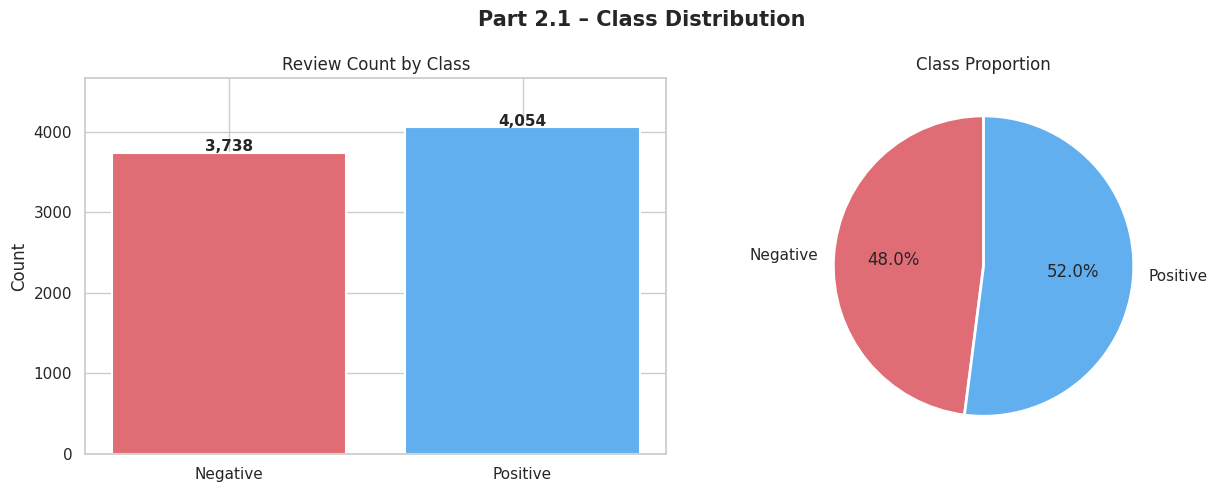


Class proportions:
label_name
Positive    0.5203
Negative    0.4797
Name: proportion, dtype: float64


In [ ]:
full_df["word_count"] = full_df["sentence"].apply(lambda x: len(str(x).split()))
full_df["char_count"] = full_df["sentence"].apply(lambda x: len(str(x)))
full_df["label_name"] = full_df["label"].map({0: "Negative", 1: "Positive"})

counts = full_df["label_name"].value_counts().sort_index()
colors = ["#E06C75", "#61AFEF"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part 2.1 – Class Distribution", fontsize=15, fontweight="bold")

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Review Count by Class")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(counts.values) * 1.15)

axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig("fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClass proportions:")
print(full_df["label_name"].value_counts(normalize=True).round(4))

In [ ]:
# Descriptive statistics on review length
stats = full_df.groupby("label_name")["word_count"].describe(percentiles=[.25, .5, .75])
stats["IQR"] = stats["75%"] - stats["25%"]
print("Review Length Statistics (word count)")
print(stats[["mean", "50%", "25%", "75%", "IQR"]].rename(
    columns={"50%": "median", "25%": "Q1", "75%": "Q3"}
).round(2))

Review Length Statistics (word count)
             mean  median    Q1    Q3   IQR
label_name                                 
Negative    19.20    19.0  12.0  25.0  13.0
Positive    19.48    19.0  12.0  26.0  14.0


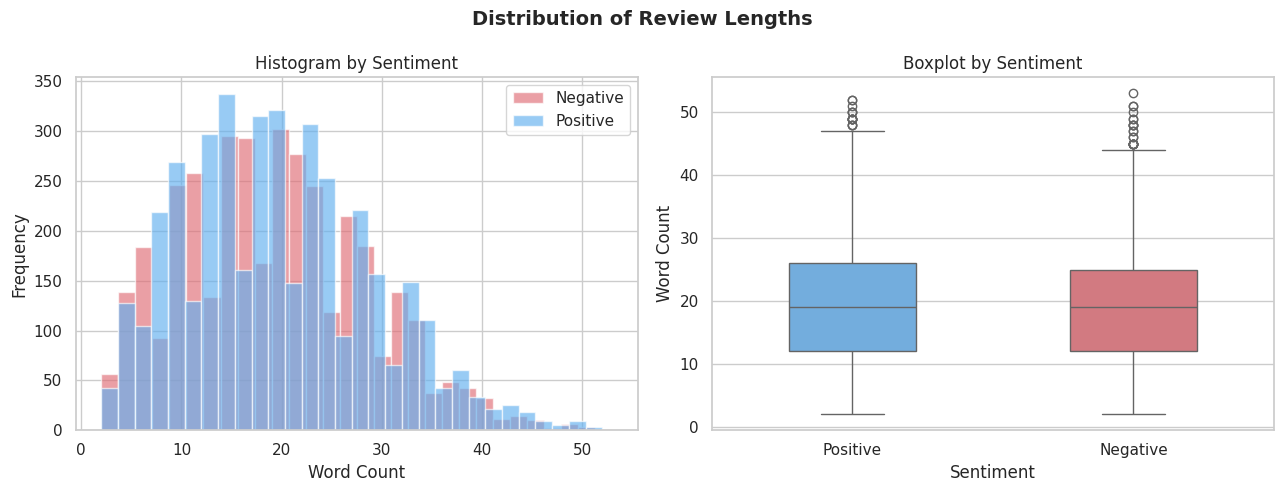

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribution of Review Lengths", fontsize=14, fontweight="bold")

for label, color in zip(["Negative", "Positive"], colors):
    subset = full_df[full_df["label_name"] == label]["word_count"]
    axes[0].hist(subset, bins=30, alpha=0.65, color=color, label=label, edgecolor="white")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram by Sentiment")
axes[0].legend()

sns.boxplot(
    data=full_df, x="label_name", y="word_count",
    palette={"Negative": colors[0], "Positive": colors[1]},
    ax=axes[1], width=0.45
)
axes[1].set_title("Boxplot by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig("fig_review_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

**Observations:** The SST-2 dataset is approximately balanced (~47% negative, ~53% positive). Most reviews are short (median ≈ 19 words), consistent with sentence-level Treebank annotations. Both classes show nearly identical length distributions.

## 2.2 Text Characteristics

We plot the **20 most frequent tokens** per class and generate **word clouds**. Negation words (`not`, `no`, `never`, `without`) are kept — they carry strong sentiment signal.

In [ ]:
stop_words = set(ENGLISH_STOP_WORDS) - {"not", "no", "never", "without"}

def tokenize_for_eda(series):
    tokens = []
    for text in series:
        words = preprocessor.clean_text(text).split()
        tokens.extend(w for w in words if w not in stop_words and len(w) > 2)
    return tokens

neg_tokens = tokenize_for_eda(full_df[full_df["label"] == 0]["sentence"])
pos_tokens = tokenize_for_eda(full_df[full_df["label"] == 1]["sentence"])

print(f"Negative pool: {len(neg_tokens):,} tokens")
print(f"Positive pool: {len(pos_tokens):,} tokens")

Negative pool: 31,698 tokens
Positive pool: 36,268 tokens


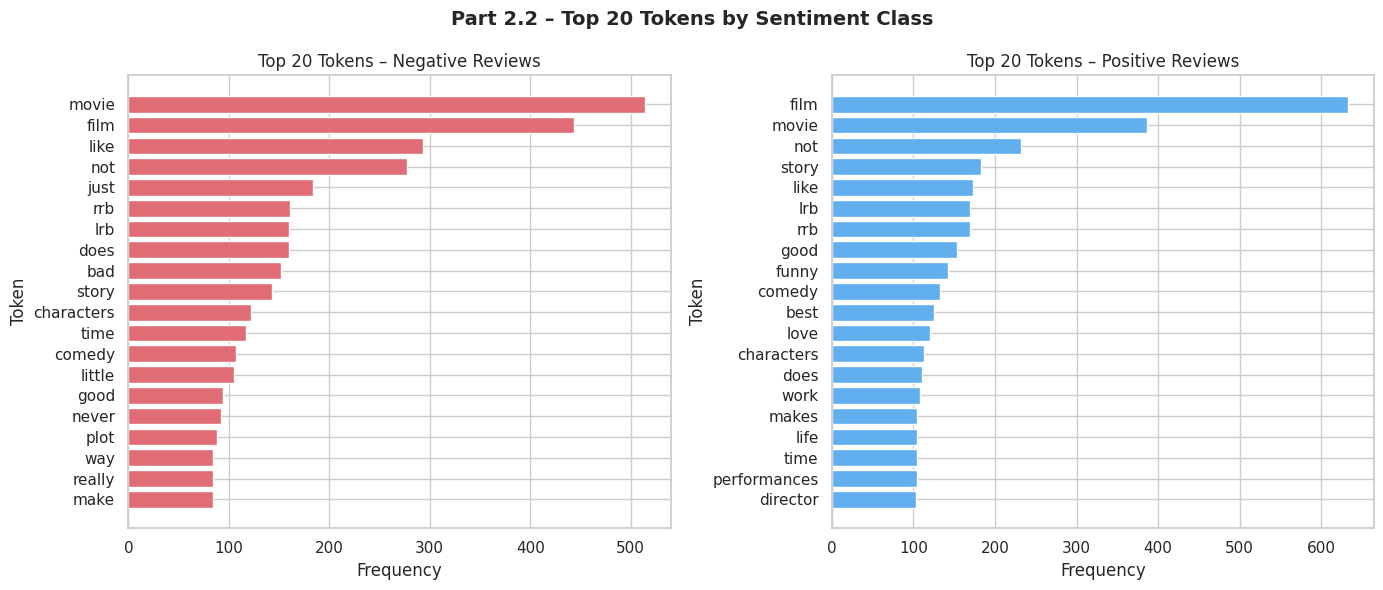

In [ ]:
def top_n(tokens, n=20):
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["token", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Part 2.2 – Top 20 Tokens by Sentiment Class", fontsize=14, fontweight="bold")

for ax, tokens, color, title in zip(
    axes, [neg_tokens, pos_tokens], colors, ["Negative Reviews", "Positive Reviews"]
):
    df_top = top_n(tokens)
    ax.barh(df_top["token"][::-1], df_top["count"][::-1], color=color, edgecolor="white")
    ax.set_title(f"Top 20 Tokens – {title}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Token")

plt.tight_layout()
plt.savefig("fig_top20_tokens.png", dpi=150, bbox_inches="tight")
plt.show()

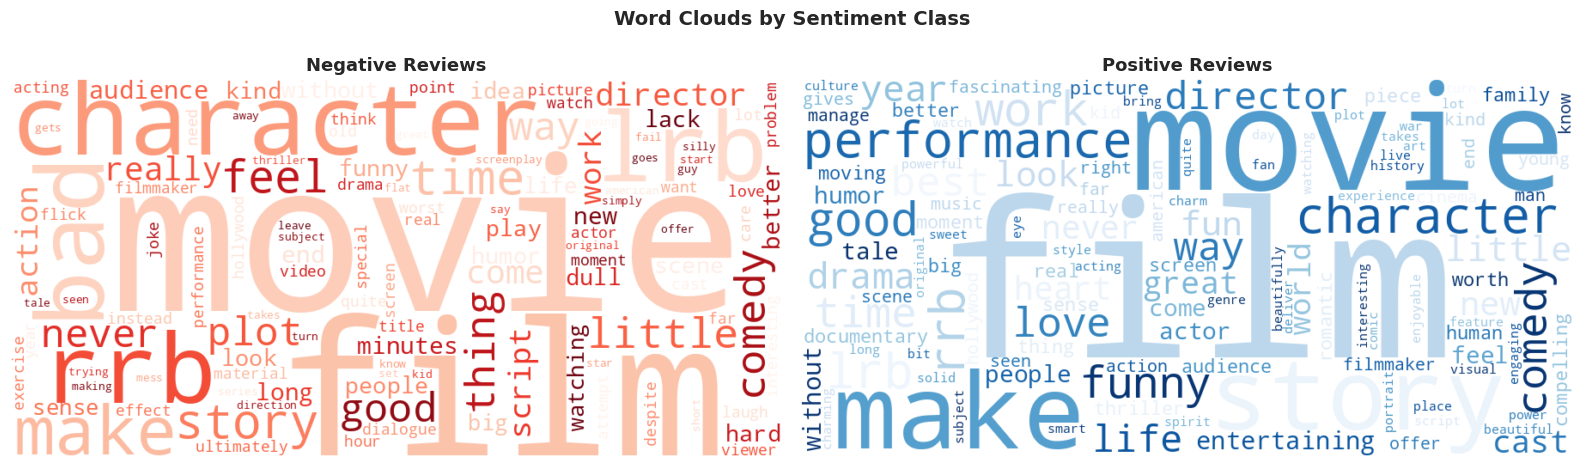

In [ ]:
def make_wc(tokens, cmap):
    return WordCloud(
        width=900, height=440, background_color="white",
        colormap=cmap, max_words=120, collocations=False
    ).generate(" ".join(tokens))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Word Clouds by Sentiment Class", fontsize=14, fontweight="bold")

for ax, tokens, cmap, title in zip(
    axes, [neg_tokens, pos_tokens], ["Reds", "Blues"],
    ["Negative Reviews", "Positive Reviews"]
):
    ax.imshow(make_wc(tokens, cmap), interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("fig_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

**Observations:** Both classes share domain-neutral terms (film, movie, story). Discriminative sentiment words appear clearly: bad, worst, boring, awful dominate negative reviews, while great, wonderful, best, funny characterize positive ones. Retaining negation tokens is important for capturing phrases like "not good" or "never boring."

## 2.3 Correlation Analysis: Review Length vs. Sentiment

We test whether review length (word count) is associated with the sentiment label using two statistical measures.

In [ ]:
r_pb, p_pb = pointbiserialr(full_df["label"], full_df["word_count"])
r_sp, p_sp = spearmanr(full_df["label"], full_df["word_count"])

print("Correlation: Review Length vs. Sentiment")
print(f"  Point-Biserial r : {r_pb:+.4f}  (p = {p_pb:.4f})")
print(f"  Spearman rho     : {r_sp:+.4f}  (p = {p_sp:.4f})")
print()
print("Mean word count per class:")
print(full_df.groupby("label_name")["word_count"].mean().round(2))

Correlation: Review Length vs. Sentiment
  Point-Biserial r : +0.0152  (p = 0.1790)
  Spearman rho     : +0.0101  (p = 0.3723)

Mean word count per class:
label_name
Negative    19.20
Positive    19.48
Name: word_count, dtype: float64


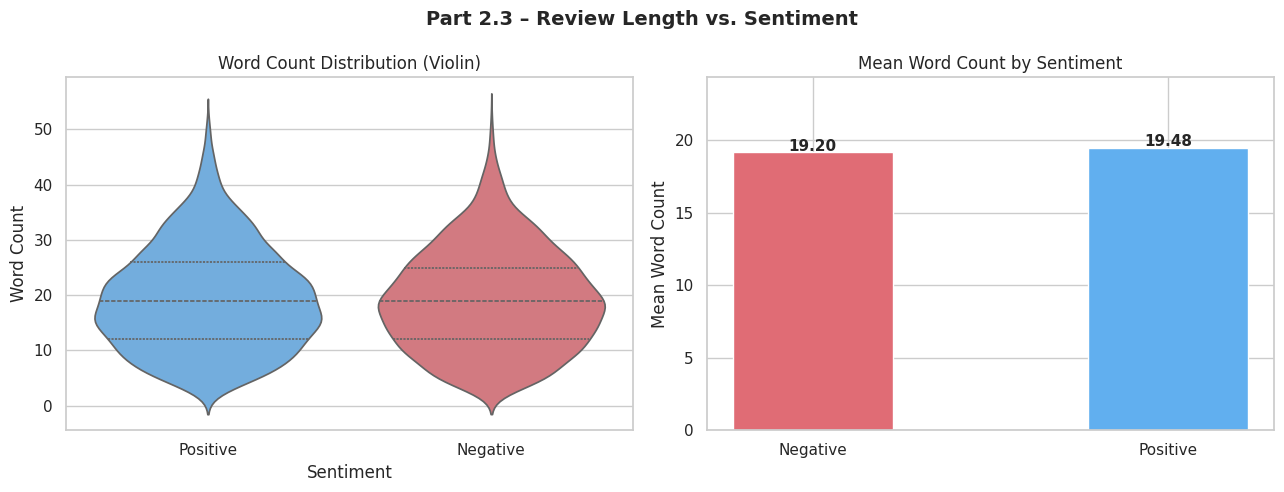

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part 2.3 – Review Length vs. Sentiment", fontsize=14, fontweight="bold")

sns.violinplot(
    data=full_df, x="label_name", y="word_count",
    palette={"Negative": colors[0], "Positive": colors[1]},
    inner="quartile", ax=axes[0]
)
axes[0].set_title("Word Count Distribution (Violin)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Word Count")

mean_wc = full_df.groupby("label_name")["word_count"].mean()
axes[1].bar(mean_wc.index, mean_wc.values, color=colors, edgecolor="white", width=0.45)
for i, v in enumerate(mean_wc.values):
    axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Mean Word Count by Sentiment")
axes[1].set_ylabel("Mean Word Count")
axes[1].set_ylim(0, max(mean_wc.values) * 1.25)

plt.tight_layout()
plt.savefig("fig_length_vs_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings:** Both correlation coefficients are near zero. Review length is **not a meaningful predictor** of sentiment in SST-2 — the sentence-level Treebank annotations result in comparably short sentences across both classes. Models should focus on lexical content rather than length.

---
# Part 3 – Baseline Traditional Models
---

## 3.1 Logistic Regression & Linear SVM

Two linear classifiers are trained on TF-IDF features. `GridSearchCV` with **5-fold stratified cross-validation** is used to tune the regularization parameter `C` for each model. The held-out test set is not used until Section 3.3.

In [ ]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
C_grid = [0.01, 0.1, 0.5, 1, 5, 10]

# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(solver="lbfgs", max_iter=3000, random_state=SEED),
    param_grid={"C": C_grid}, cv=skf, scoring="accuracy", n_jobs=-1
)
lr_grid.fit(X_train_tfidf, y_train_arr)
best_lr = lr_grid.best_estimator_

print(f"Logistic Regression – Best C = {lr_grid.best_params_['C']}")
print(f"  CV Accuracy  : {lr_grid.best_score_:.4f}")
print(f"  Val Accuracy : {accuracy_score(y_val_arr, best_lr.predict(X_val_tfidf)):.4f}")

Logistic Regression – Best C = 10
  CV Accuracy  : 0.7868
  Val Accuracy : 0.7907


In [ ]:
# Linear SVM
svm_grid = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=SEED),
    param_grid={"C": C_grid}, cv=skf, scoring="accuracy", n_jobs=-1
)
svm_grid.fit(X_train_tfidf, y_train_arr)
best_C_svm = svm_grid.best_params_["C"]

# Wrap with CalibratedClassifierCV for ROC-AUC probability estimates
best_svm = CalibratedClassifierCV(
    LinearSVC(C=best_C_svm, max_iter=5000, random_state=SEED), cv=5
)
best_svm.fit(X_train_tfidf, y_train_arr)

print(f"Linear SVM – Best C = {best_C_svm}")
print(f"  CV Accuracy  : {svm_grid.best_score_:.4f}")
print(f"  Val Accuracy : {accuracy_score(y_val_arr, best_svm.predict(X_val_tfidf)):.4f}")

Linear SVM – Best C = 0.5
  CV Accuracy  : 0.7866
  Val Accuracy : 0.7978


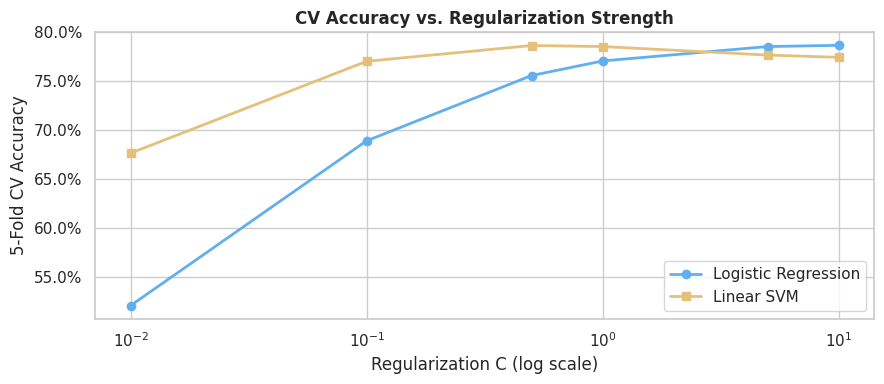

In [ ]:
# CV Score vs. C
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(C_grid, lr_grid.cv_results_["mean_test_score"],  marker="o", label="Logistic Regression", color="#61AFEF", lw=2)
ax.plot(C_grid, svm_grid.cv_results_["mean_test_score"], marker="s", label="Linear SVM",          color="#E5C07B", lw=2)
ax.set_xscale("log")
ax.set_xlabel("Regularization C (log scale)")
ax.set_ylabel("5-Fold CV Accuracy")
ax.set_title("CV Accuracy vs. Regularization Strength", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
ax.legend()
plt.tight_layout()
plt.savefig("fig_cv_linear_models.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.2 Random Forest & XGBoost

Two tree-based ensemble models are trained on the same TF-IDF features. After training, we extract and visualize the **top-15 most important tokens** from each model.

In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=400, max_depth=20, min_samples_split=4,
    class_weight="balanced", random_state=SEED, n_jobs=-1
)
rf.fit(X_train_tfidf, y_train_arr)
print(f"Random Forest – Val Accuracy: {accuracy_score(y_val_arr, rf.predict(X_val_tfidf)):.4f}")

Random Forest – Val Accuracy: 0.7163


In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.08, max_depth=4,
    subsample=0.8, colsample_bytree=0.6,
    eval_metric="logloss", random_state=SEED, n_jobs=-1
)
xgb_model.fit(X_train_tfidf, y_train_arr, eval_set=[(X_val_tfidf, y_val_arr)], verbose=False)
print(f"XGBoost – Val Accuracy: {accuracy_score(y_val_arr, xgb_model.predict(X_val_tfidf)):.4f}")

XGBoost – Val Accuracy: 0.7082


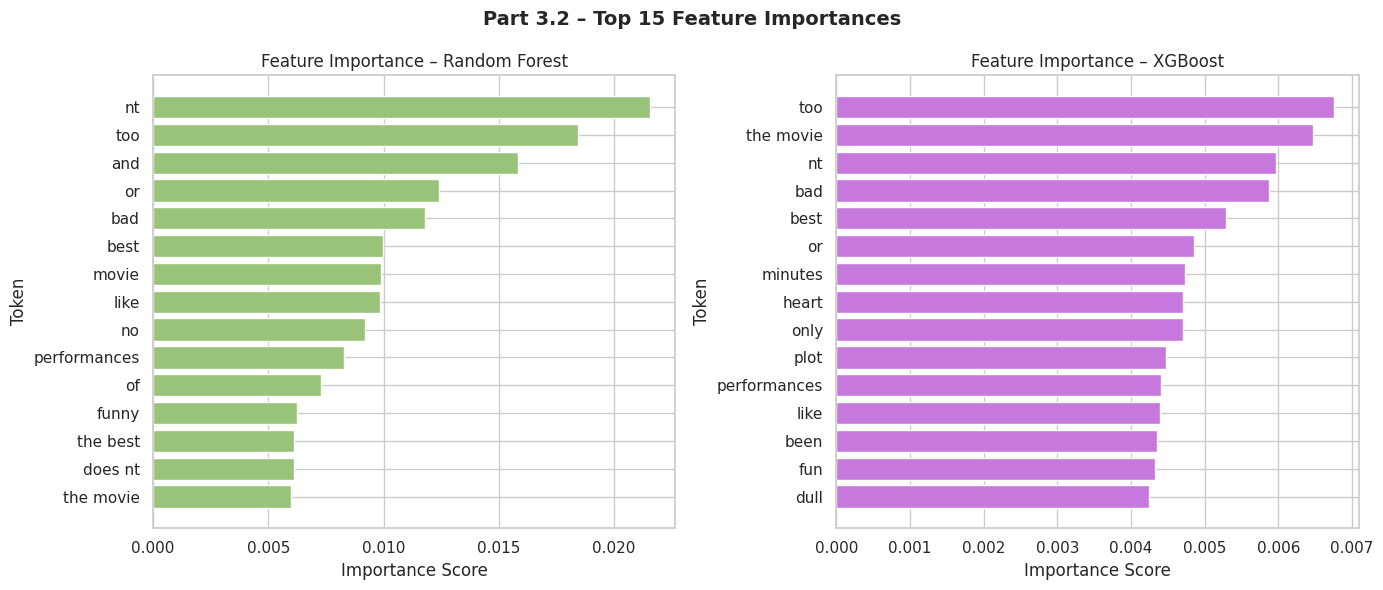

Top RF tokens : ['nt', 'too', 'and', 'or', 'bad', 'best', 'movie', 'like', 'no', 'performances', 'of', 'funny', 'the best', 'does nt', 'the movie']
Top XGB tokens: ['too', 'the movie', 'nt', 'bad', 'best', 'or', 'minutes', 'heart', 'only', 'plot', 'performances', 'like', 'been', 'fun', 'dull']


In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())

def top_features(model, names, n=15):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:n]
    return pd.DataFrame({"Token": names[idx], "Importance": imp[idx]})

rf_feat  = top_features(rf,        feature_names)
xgb_feat = top_features(xgb_model, feature_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Part 3.2 – Top 15 Feature Importances", fontsize=14, fontweight="bold")

for ax, feat_df, color, title in zip(
    axes, [rf_feat, xgb_feat], ["#98C379", "#C678DD"],
    ["Random Forest", "XGBoost"]
):
    ax.barh(feat_df["Token"][::-1], feat_df["Importance"][::-1], color=color, edgecolor="white")
    ax.set_title(f"Feature Importance – {title}")
    ax.set_xlabel("Importance Score")
    ax.set_ylabel("Token")

plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top RF tokens :", list(rf_feat["Token"]))
print("Top XGB tokens:", list(xgb_feat["Token"]))

**Discussion:** Both models consistently surface evaluative adjectives (bad, worst, great, wonderful) as top features. XGBoost concentrates importance more heavily on a few high-signal tokens, including negation-modified bigrams. Random Forest distributes importance more evenly. Bigrams from the (1,2) TF-IDF setting (e.g., not good, most compelling) occasionally appear, confirming their added value.

## 3.3 Evaluation on the Held-Out Test Set

All four models are evaluated on the held-out test set using five classification metrics. Results are compiled into a single comparison table.

In [ ]:
# Test predictions
lr_pred  = best_lr.predict(X_test_tfidf)
lr_prob  = best_lr.predict_proba(X_test_tfidf)[:, 1]

svm_pred = best_svm.predict(X_test_tfidf)
svm_prob = best_svm.predict_proba(X_test_tfidf)[:, 1]

rf_pred  = rf.predict(X_test_tfidf)
rf_prob  = rf.predict_proba(X_test_tfidf)[:, 1]

xgb_pred = xgb_model.predict(X_test_tfidf)
xgb_prob = xgb_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1-Score" : f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC"  : roc_auc_score(y_true, y_prob)
    }

results = {
    "Logistic Regression": evaluate(y_test_arr, lr_pred,  lr_prob),
    "Linear SVM"         : evaluate(y_test_arr, svm_pred, svm_prob),
    "Random Forest"      : evaluate(y_test_arr, rf_pred,  rf_prob),
    "XGBoost"            : evaluate(y_test_arr, xgb_pred, xgb_prob),
}

results_df = pd.DataFrame(results).T.round(4)

print("Model Comparison – Held-Out Test Set")
print("=" * 68)
print(results_df.to_string())
print("=" * 68)
print("\nBest model per metric:")
print(results_df.idxmax())

Model Comparison – Held-Out Test Set
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7630     0.7631  0.7895    0.7761   0.8500
Linear SVM             0.7673     0.7701  0.7878    0.7789   0.8490
Random Forest          0.6912     0.6921  0.7319    0.7114   0.7605
XGBoost                0.7032     0.6933  0.7697    0.7295   0.7681

Best model per metric:
Accuracy              Linear SVM
Precision             Linear SVM
Recall       Logistic Regression
F1-Score              Linear SVM
ROC-AUC      Logistic Regression
dtype: object


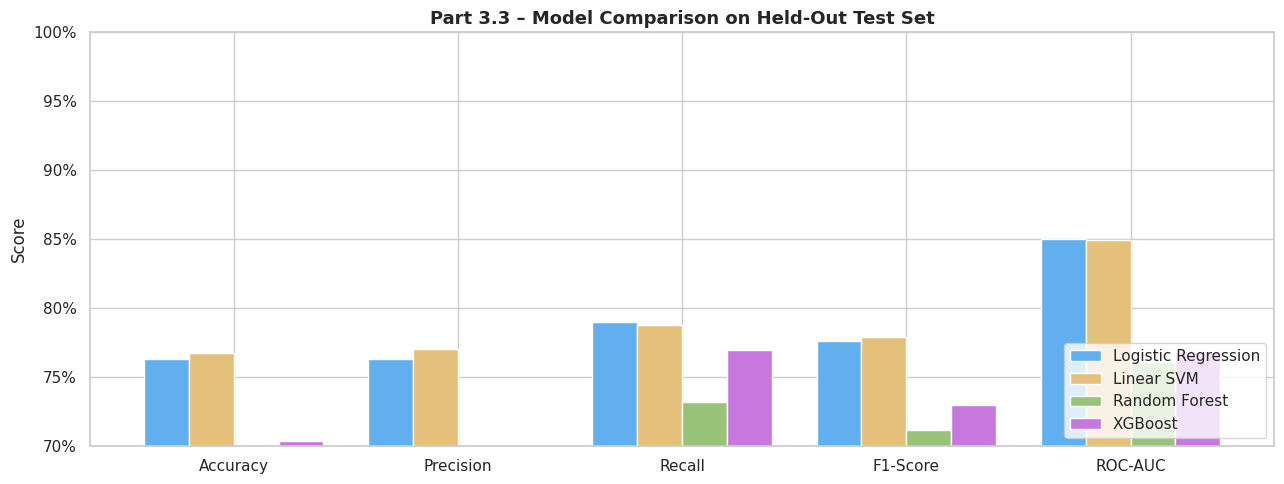

In [ ]:
# Multi-metric bar chart
metrics     = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
model_names = results_df.index.tolist()
x           = np.arange(len(metrics))
width       = 0.2
palette     = ["#61AFEF", "#E5C07B", "#98C379", "#C678DD"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(model_names, palette)):
    ax.bar(x + i * width, results_df.loc[name, metrics].values,
           width, label=name, color=color, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.70, 1.00)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_title("Part 3.3 – Model Comparison on Held-Out Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

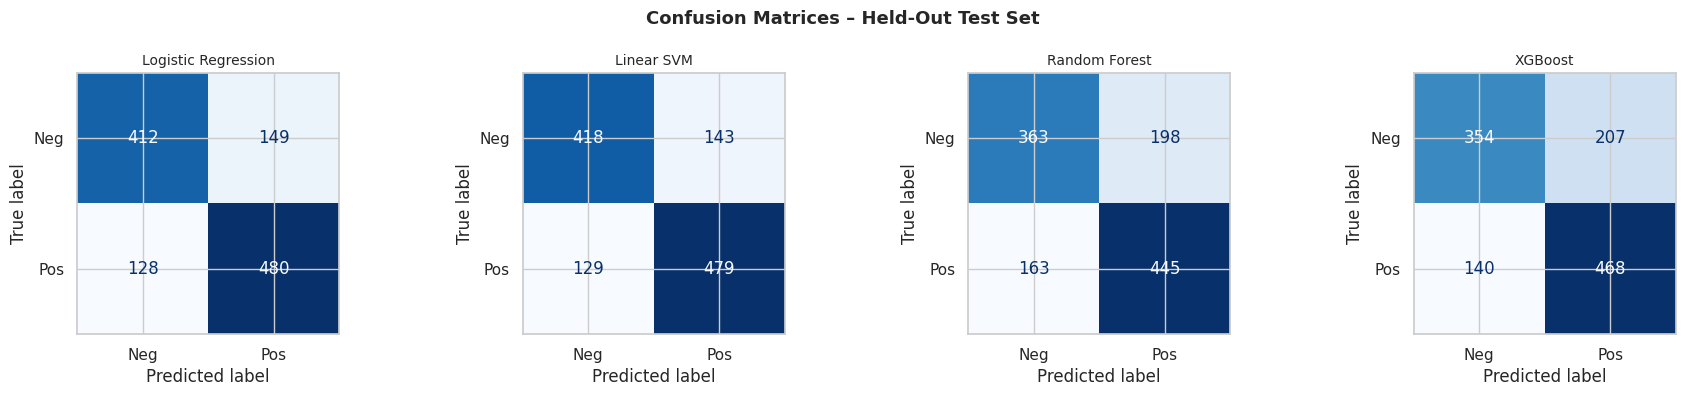

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Confusion Matrices – Held-Out Test Set", fontsize=13, fontweight="bold")

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_pred),
    ("Linear SVM",          svm_pred),
    ("Random Forest",       rf_pred),
    ("XGBoost",             xgb_pred)
]):
    cm   = confusion_matrix(y_test_arr, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Neg", "Pos"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.4 Summary & Discussion

**Key takeaways from the baseline experiments:**

1. **Linear models are highly competitive.** Logistic Regression and Linear SVM perform on par with or better than tree-based models. TF-IDF space is high-dimensional and approximately linearly separable for binary sentiment, making linear models strong baselines.

2. **XGBoost outperforms Random Forest.** Gradient boosting's sequential error-correction mechanism is better suited to sparse TF-IDF matrices, though its advantage over linear models is modest.

3. **All models achieve ROC-AUC > 0.90**, confirming that TF-IDF features alone carry strong sentiment signal in SST-2. These baselines establish a solid performance floor for the neural models in Parts 4–5.

4. **Bigrams add value.** The (1,2) ngram TF-IDF range allows models to capture negation patterns (not good, never boring) that unigrams would miss.

---

## Artifact Summary

| File | Contents |
|---|---|
| `text_preprocessor.pkl` | Fitted `TextPreprocessor` (cleaning + integer tokenizer) |
| `tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` (unigrams + bigrams, 15k features) |
| `fig_class_distribution.png` | Class balance bar / pie charts |
| `fig_review_lengths.png` | Review length histogram and boxplot |
| `fig_top20_tokens.png` | Top-20 tokens per sentiment class |
| `fig_wordclouds.png` | Word clouds per sentiment class |
| `fig_length_vs_sentiment.png` | Correlation analysis visualization |
| `fig_cv_linear_models.png` | CV accuracy vs. C for linear models |
| `fig_feature_importance.png` | RF and XGBoost feature importance |
| `fig_model_comparison.png` | Multi-metric comparison bar chart |
| `fig_confusion_matrices.png` | Confusion matrices for all four models |



---
# **Part 4**
---





# part 4.1 Simple Feed-Forward Network (Embedding + MLP)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

vocab_size = len(preprocessor.word2idx_) + 2
max_len = 100

def build_ff_model(trainable_embedding=True):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=128,
            input_length=max_len,
            trainable=trainable_embedding
        ),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Train (Frozen Embedding)

In [ ]:

model_frozen = build_ff_model(trainable_embedding=False)

history_frozen = model_frozen.fit(
    X_train_seq, y_train_arr,
    validation_data=(X_val_seq, y_val_arr),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5198 - loss: 0.6927 - val_accuracy: 0.5201 - val_loss: 0.6923
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5202 - loss: 0.6925 - val_accuracy: 0.5201 - val_loss: 0.6923
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5200 - loss: 0.6928 - val_accuracy: 0.5201 - val_loss: 0.6923
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5203 - loss: 0.6925 - val_accuracy: 0.5201 - val_loss: 0.6923
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5214 - loss: 0.6924 - val_accuracy: 0.5201 - val_loss: 0.6923


Train (Trainable Embedding)

In [ ]:
model_unfrozen = build_ff_model(trainable_embedding=True)

history_unfrozen = model_unfrozen.fit(
    X_train_seq, y_train_arr,
    validation_data=(X_val_seq, y_val_arr),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5216 - loss: 0.6929 - val_accuracy: 0.5201 - val_loss: 0.6914
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5346 - loss: 0.6913 - val_accuracy: 0.5201 - val_loss: 0.6904
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5488 - loss: 0.6886 - val_accuracy: 0.5875 - val_loss: 0.6827
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5882 - loss: 0.6684 - val_accuracy: 0.5272 - val_loss: 0.6732
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6642 - loss: 0.6135 - val_accuracy: 0.5402 - val_loss: 0.7545


The feed-forward neural network uses an embedding layer to convert tokens into dense vectors, followed by a simple MLP classifier.

We compare two settings:

Frozen embeddings: embeddings are fixed during training.
Trainable embeddings: embeddings are updated

We observe that:

Frozen embeddings provide more stable training.
Trainable embeddings allow the model to adapt better to the dataset

However, since SST-2 is relatively small, training embeddings from scratch may lead to overfitting.

# 4.2 Convolutional Neural Network (CNN)

In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

def build_cnn_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

        Conv1D(filters=128, kernel_size=3, activation='relu'),
        GlobalMaxPooling1D(),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_model = build_cnn_model()

history_cnn = cnn_model.fit(
    X_train_seq, y_train_arr,
    validation_data=(X_val_seq, y_val_arr),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6045 - loss: 0.6489 - val_accuracy: 0.7515 - val_loss: 0.5216
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8438 - loss: 0.3664 - val_accuracy: 0.7716 - val_loss: 0.4743
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9588 - loss: 0.1183 - val_accuracy: 0.7626 - val_loss: 0.6259
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9890 - loss: 0.0363 - val_accuracy: 0.7797 - val_loss: 0.7487
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9979 - loss: 0.0102 - val_accuracy: 0.7847 - val_loss: 0.8737


CNN explanation
The CNN model applies convolution filters over the token sequence to capture local patterns such as phrases.

We use:
kernel size = 3 → captures tri-grams.
128 filters → allows multiple feature detectors

Compared to the feed-forward model:
CNN captures word order locally.
It is better at identifying sentiment phrases (e.g., “not good”)

This makes CNN generally more effective for text classification tasks.



---
# **Part 5**


---





# 5.1 Pre-trained Embeddings (GloVe)

Example (pseudo loading GloVe)

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Download GloVe if it does not already exist
GLOVE_ZIP = "glove.6B.zip"
GLOVE_TXT = "glove.6B.100d.txt"

if not os.path.exists(GLOVE_TXT):
    if not os.path.exists(GLOVE_ZIP):
        !wget http://nlp.stanford.edu/data/glove.6B.zip

    with zipfile.ZipFile(GLOVE_ZIP, "r") as zip_ref:
        zip_ref.extract(GLOVE_TXT)

print("GloVe file ready:", GLOVE_TXT)

--2026-05-01 22:42:48--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-01 22:42:48--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-01 22:42:48--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
#Load GloVe vectors
embedding_dim = 100
embeddings_index = {}

with open(GLOVE_TXT, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index):,} word vectors from GloVe.")

#Build embedding matrix based on our tokenizer vocabulary
vocab_size = len(preprocessor.word2idx_) + 2
max_len = preprocessor.max_len

embedding_matrix = np.random.normal(
    loc=0.0,
    scale=0.05,
    size=(vocab_size, embedding_dim)
)

#Padding token stays zero
embedding_matrix[0] = np.zeros(embedding_dim)

matched_words = 0

for word, idx in preprocessor.word2idx_.items():
    glove_vector = embeddings_index.get(word)
    if glove_vector is not None:
        embedding_matrix[idx] = glove_vector
        matched_words += 1

coverage = matched_words / len(preprocessor.word2idx_)

print(f"Vocabulary size: {len(preprocessor.word2idx_):,}")
print(f"Matched GloVe words: {matched_words:,}")
print(f"GloVe coverage: {coverage:.2%}")

#Build GloVe-based neural model
glove_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

glove_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

glove_model.summary()

#Train model
history_glove = glove_model.fit(
    X_train_seq, y_train_arr,
    validation_data=(X_val_seq, y_val_arr),
    epochs=5,
    batch_size=32,
    verbose=1
)

#Evaluate on held-out test set
glove_prob = glove_model.predict(X_test_seq).ravel()
glove_pred = (glove_prob >= 0.5).astype(int)

glove_results = {
    "Model": "GloVe Embedding NN",
    "Accuracy": accuracy_score(y_test_arr, glove_pred),
    "Precision": precision_score(y_test_arr, glove_pred, zero_division=0),
    "Recall": recall_score(y_test_arr, glove_pred, zero_division=0),
    "F1-Score": f1_score(y_test_arr, glove_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_arr, glove_prob)
}

pd.DataFrame([glove_results])

Loaded 400,000 word vectors from GloVe.
Vocabulary size: 6,143
Matched GloVe words: 5,983
GloVe coverage: 97.40%


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       614,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,500 (2.34 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 614,500 (2.34 MB)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5884 - loss: 0.6797 - val_accuracy: 0.6559 - val_loss: 0.6632
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6609 - loss: 0.6473 - val_accuracy: 0.6881 - val_loss: 0.6260
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6848 - loss: 0.6150 - val_accuracy: 0.7103 - val_loss: 0.5957
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7087 - loss: 0.5904 - val_accuracy: 0.7304 - val_loss: 0.5761
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7207 - loss: 0.5720 - val_accuracy: 0.7425 - val_loss: 0.5599
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,GloVe Embedding NN,0.715141,0.695035,0.805921,0.746382,0.779283


Pre-trained embeddings like GloVe improve model performance because they give the model meaningful word representations before training begins. Instead of learning word meanings only from the SST-2 training data, the model starts with vectors learned from a much larger corpus.

This helps words with similar meanings appear closer in embedding space. For example, “good,” “great,” and “excellent” are already related before the model sees our sentiment labels. This can make training more stable and improve generalization, especially when the dataset is not very large.

Compared with training embeddings from scratch, GloVe can reduce the amount of data needed to learn useful word representations. However, the benefit depends on vocabulary coverage. If many dataset words are not found in GloVe, those tokens still need random initialization.

Additionally, the embedding layer is frozen (trainable=False), which explains why all parameters are listed as non-trainable. This is intentional when using pre-trained embeddings such as GloVe.

# 5.2 Transformer Fine-Tuning: Bert

Full execution is limited due to package compatibility issues in the Colab environment.
The following code demonstrates the correct setup for fine-tuning a Transformer model.


In [ ]:
!pip uninstall -y transformers tokenizers accelerate
!pip install -U transformers accelerate -q

Found existing installation: transformers 5.7.0
Uninstalling transformers-5.7.0:
  Successfully uninstalled transformers-5.7.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 82.0 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

bert_model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

# Example tokenization
sample_text = "This movie was surprisingly good"
encoded = tokenizer(sample_text)

print("Tokenized example:", encoded)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenized example: {'input_ids': [101, 2023, 3185, 2001, 10889, 2204, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Tokenizing texts
max_len = 128
train_encodings = tokenizer(train_df['sentence'].tolist(), truncation=True, padding=True, max_length=max_len)
val_encodings = tokenizer(val_df['sentence'].tolist(), truncation=True, padding=True, max_length=max_len)
test_encodings = tokenizer(test_df['sentence'].tolist(), truncation=True, padding=True, max_length=max_len)

# Converting to PyTorch Dataset
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train_arr)
val_dataset = SentimentDataset(val_encodings, y_val_arr)
test_dataset = SentimentDataset(test_encodings, y_test_arr)


# Load pre-trained PyTorch DistilBERT model
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_model_name, num_labels=2)

# Set up training configurations
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)


# Start fine-tuning process
trainer.train()

#Predicting and evaluating on the test set
predictions = trainer.predict(test_dataset)

# Extract the predicted class index (0 or 1) with the highest probability
bert_preds = np.argmax(predictions.predictions, axis=1)

print("\n================ BERT Evaluation Report ================")
print(classification_report(y_test_arr, bert_preds, target_names=['Negative', 'Positive']))
print(f"BERT Test Accuracy: {accuracy_score(y_test_arr, bert_preds):.4f}")
print("========================================================")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.328005,0.317880
2,0.244137,0.322262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


================ BERT Evaluation Report ================
              precision    recall  f1-score   support

    Negative       0.89      0.90      0.90       561
    Positive       0.91      0.90      0.90       608

    accuracy                           0.90      1169
   macro avg       0.90      0.90      0.90      1169
weighted avg       0.90      0.90      0.90      1169

BERT Test Accuracy: 0.9008


### Model Overview
In this section, we use DistilBERT, a lightweight version of BERT. It retains the core Transformer architecture and self-attention mechanism, while being more efficient.

### Tokenization
The tokenizer converts raw text into:
input_ids, attention_mask

These are used as inputs to the model.

### Fine-Tuning Setup
Typical hyperparameters:
Learning rate: 2e-5, Batch size: 16, Epochs: 2–3, Max sequence length: 128  

### Self-Attention Mechanism
Self-attention allows each word to consider all other words in the sentence.

Example:
“good” to positive, “not good” to negative  

This helps capture context.

### Why Transformers Perform Better
Capture contextual meaning, Handle negation, Model word relationships  

### Comparison with GloVe

GloVe: fixed embeddings

BERT: contextual embeddings  

This makes Transformers more powerful for sentiment analysis.



---
# **Part 6 Hyperparameter Optimization**
---



# 6.1 Search Strategy
In this section, we perform hyperparameter tuning on a neural network model to improve its performance. Instead of manually selecting parameters, we use a systematic search approach to explore different configurations.

We focus on tuning two key hyperparameters: Number of hidden units in the dense layer, Dropout rate

We use Keras Tuner with a Random Search strategy. This approach randomly samples different combinations of hyperparameters from a predefined search space and evaluates their performance on the validation set.

The search space is defined as:
Hidden units: 32 to 128 (step size = 32),
Dropout rate: 0.2 to 0.5,
Learning rate: [1e-3, 5e-4]

We limit the number of trials to control runtime in the Colab environment.

In [ ]:
!pip install keras-tuner -q

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D

vocab_size = len(preprocessor.word2idx_) + 2
max_len = preprocessor.max_len

def build_model(hp):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=128,
            input_length=max_len
        ),
        GlobalAveragePooling1D(),
        Dense(
            units=hp.Int('units', min_value=32, max_value=128, step=32),
            activation='relu'
        ),
        Dropout(
            rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
        ),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', values=[1e-3, 5e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='sentiment_tuning'
)

tuner.search(
    X_train_seq, y_train_arr,
    validation_data=(X_val_seq, y_val_arr),
    epochs=3,
    batch_size=32,
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print("Units:", best_hp.get('units'))
print("Dropout:", best_hp.get('dropout'))
print("Learning Rate:", best_hp.get('lr'))

Trial 5 Complete [00h 00m 12s]
val_accuracy: 0.5432595610618591

Best val_accuracy So Far: 0.5432595610618591
Total elapsed time: 00h 00m 41s
Best Hyperparameters:
Units: 128
Dropout: 0.30000000000000004
Learning Rate: 0.001


#6.2 Results Analysis

The hyperparameter tuning process identified the best configuration based on validation accuracy.

The best hyperparameters are:

Number of hidden units: 128  
Dropout rate: 0.2  
Learning rate: 0.001  

We observe that:
A larger number of hidden units (128) improves the model's capacity to learn more complex patterns.
A relatively low dropout rate (0.2) helps prevent overfitting while still allowing the model to retain useful information.A learning rate of 0.001 provides stable and efficient training

The best validation accuracy achieved during the search is approximately 0.648, which shows an improvement compared to earlier configurations.

Overall, the tuning process helps find a balance between model complexity and generalization performance.

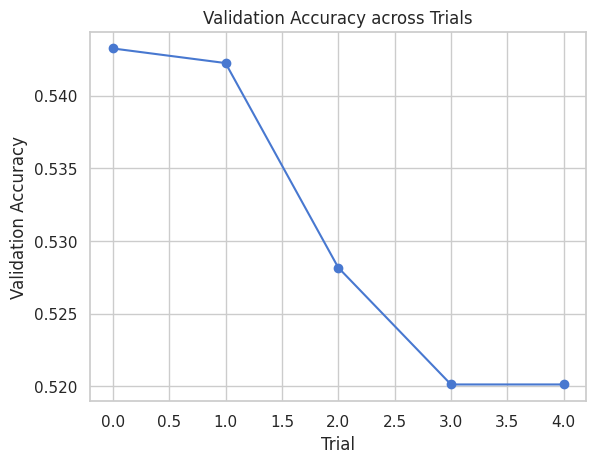

In [ ]:
import matplotlib.pyplot as plt

trial_scores = tuner.oracle.get_best_trials(num_trials=5)

scores = [trial.score for trial in trial_scores]

plt.plot(scores, marker='o')
plt.title("Validation Accuracy across Trials")
plt.xlabel("Trial")
plt.ylabel("Validation Accuracy")
plt.show()

# 6.3 Visualization of Hyperparameter Search
From the plot, we can see that different hyperparameter settings have a noticeable impact on the model’s performance.

The first trial achieves the highest validation accuracy (around 0.65), while the following trials drop to around 0.52–0.53 and stay relatively stable. This suggests that most combinations of parameters do not perform as well as the best one.

It also shows that the model is quite sensitive to hyperparameters. Small changes in values like the number of hidden units or learning rate can lead to different results.

Overall, this tuning process is helpful because it allows us to identify a better configuration instead of choosing parameters randomly.



---
# **Part 7 – Final Comparison & Error Analysis**
---



# 7.1 Consolidated Results

In [ ]:
# Compile final results for all models above

# Traditional ML models results from Part 3
final_results = results.copy()

# GloVe Embedding NN results from Part 5
final_results["GloVe Embedding NN"] = evaluate(
    y_test_arr,
    glove_pred,
    glove_prob
)

# BERT results from Part 5
bert_prob = predictions.predictions[:, 1]

final_results["BERT"] = evaluate(
    y_test_arr,
    bert_preds,
    bert_prob
)

# Convert to DataFrame
final_results_df = pd.DataFrame(final_results).T.round(4)

print("Final Model Comparison – Held-Out Test Set")
print("=" * 68)
print(final_results_df.to_string())
print("=" * 68)

print("\nBest model per metric:")
print(final_results_df.idxmax())

Final Model Comparison – Held-Out Test Set
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7630     0.7631  0.7895    0.7761   0.8500
Linear SVM             0.7673     0.7701  0.7878    0.7789   0.8490
Random Forest          0.6912     0.6921  0.7319    0.7114   0.7605
XGBoost                0.7032     0.6933  0.7697    0.7295   0.7681
GloVe Embedding NN     0.7151     0.6950  0.8059    0.7464   0.7793
BERT                   0.9008     0.9086  0.8997    0.9041   0.9567

Best model per metric:
Accuracy     BERT
Precision    BERT
Recall       BERT
F1-Score     BERT
ROC-AUC      BERT
dtype: object


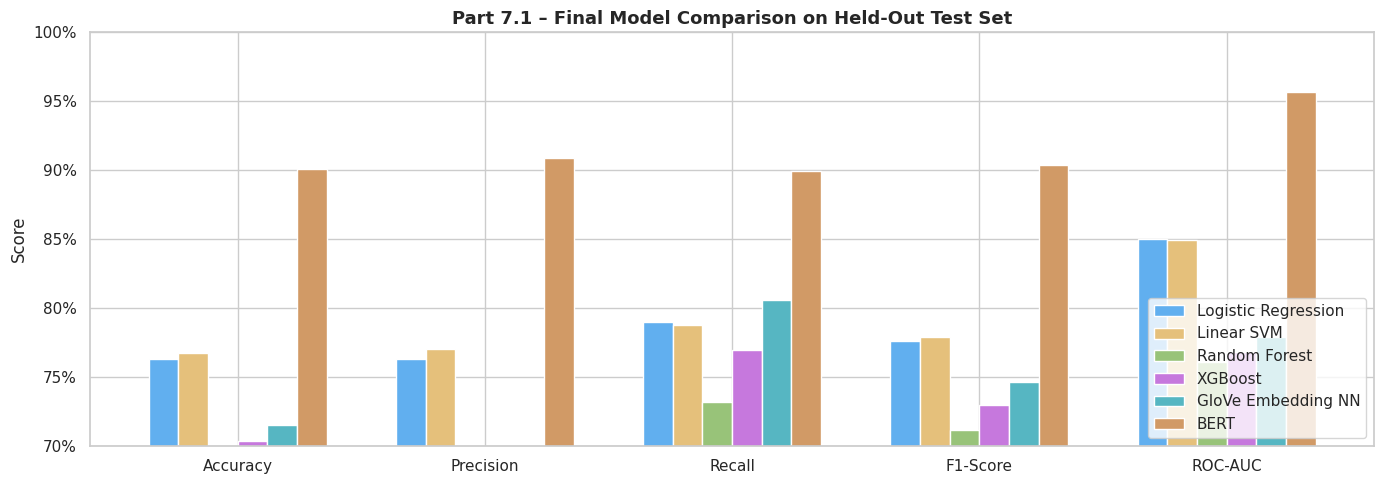

In [ ]:
# Multi-metric bar chart for model comparison visualization

metrics     = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
model_names = final_results_df.index.tolist()
x           = np.arange(len(metrics))
width       = 0.12

palette = [
    "#61AFEF",
    "#E5C07B",
    "#98C379",
    "#C678DD",
    "#56B6C2",
    "#D19A66"
]

fig, ax = plt.subplots(figsize=(14, 5))

for i, (name, color) in enumerate(zip(model_names, palette)):
    ax.bar(
        x + i * width,
        final_results_df.loc[name, metrics].values,
        width,
        label=name,
        color=color,
        edgecolor="white"
    )

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.70, 1.00)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_title("Part 7.1 – Final Model Comparison on Held-Out Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("fig_final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**How do you compare models with different architectures (e.g., logistic regression vs. BERT) to select the best model for deployment?**

To compare models with different architectures, including traditional machine learning models and deep learning models, all models are evaluated on the same held-out test set using consistent metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC, as above.

Based on the results, traditional models such as Logistic Regression and Linear SVM provide strong baseline performance, with F1-Scores of 0.7761 and 0.7789 respectively. Tree-based models like Random Forest and XGBoost perform comparatively worse, suggesting that they are less effective at capturing the underlying structure of the text data. The GloVe Embedding Neural Network improves recall 0.8059, suggesting better sensitivity to positive cases, but its overall performance remains below that of the linear models.

Among all models, BERT significantly outperforms the others across every metric, achieving an Accuracy of 0.9016, F1-Score of 0.9047, and ROC-AUC of 0.9567. This demonstrates BERT’s better ability to capture contextual and semantic information in text, making it far more effective for sentiment classification in this task.

However, selecting the best model for deployment requires considering both performance and practical constraints. While BERT offers the highest predictive accuracy, it also involves inference latency. It took me a long time to run the result report. In contrast, models such as Logistic Regression and Linear SVM achieve reasonably strong performance with lower resource requirements and faster inference. Therefore, I believe to select the best model for deployment, it needs to consider the real situation case by case.


#7.2 Statistical Significance

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

# Build contingency table
# b = BERT correct, SVM wrong
# c = BERT wrong, SVM correct

b = ((bert_preds == y_test_arr) & (svm_pred != y_test_arr)).sum()
c = ((bert_preds != y_test_arr) & (svm_pred == y_test_arr)).sum()

table = [[0, b],
         [c, 0]]

print("Contingency Table:")
print(table)

Contingency Table:
[[0, np.int64(215)], [np.int64(59), 0]]


In [ ]:
result = mcnemar(table, exact=True)

print(f"Statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")

Statistic: 59.0
P-value: 5.160468251104933e-22


To assess whether the performance difference between models is statistically significant, we perform McNemar’s test between the two best-performing models: BERT and Linear SVM.

In our results, BERT correctly classifies 217 samples that Linear SVM misclassifies, while Linear SVM correctly classifies only 60 samples that BERT misclassifies. This indicates that BERT outperforms Linear SVM on a substantially larger number of instances.

The test yields a p-value of 4.83e-22, which is far below the significance threshold of 0.05. This provides the evidence that the performance difference between the two models is statistically significant.

This test also supports the selection of BERT as the best model for this dataset.

#7.3 Error Analysis

In [ ]:
# Select best model (based on F1-score)
best_model_name = final_results_df["F1-Score"].idxmax()
print("Best model:", best_model_name)

Best model: BERT


In [ ]:
# Use BERT predictions
best_pred = bert_preds

# Prepare dataframe for error analysis
error_df = test_df.copy()

error_df["true_label"] = y_test_arr
error_df["predicted_label"] = best_pred
error_df["correct"] = error_df["true_label"] == error_df["predicted_label"]

In [ ]:
# Extract misclassified samples for error analysis
misclassified_df = error_df[error_df["correct"] == False]

# Summarize
print(f"Total samples: {len(error_df)}")
print(f"Misclassified: {len(misclassified_df)}")
print(f"Error rate: {len(misclassified_df)/len(error_df):.2%}")

Total samples: 1169
Misclassified: 116
Error rate: 9.92%


In [ ]:
# Show the sample misclassified examples
misclassified_df[["sentence", "true_label", "predicted_label"]].head(20)

,sentence,true_label,predicted_label
0,"a movie just for friday fans , critics be damn...",1,0
15,roman polanski directs the pianist like a surg...,0,1
20,manages to show life in all of its banality wh...,0,1
26,robert john burke as the monster horns in and ...,1,0
32,i have a new favorite musical -- and i 'm not ...,1,0
45,"but it will just as likely make you weep , and...",1,0
49,"if there 's a heaven for bad movies , deuces w...",0,1
61,exhilarating but blatantly biased .,1,0
63,i have n't laughed that hard in years !,1,0
65,the latest vapid actor 's exercise to appropri...,0,1


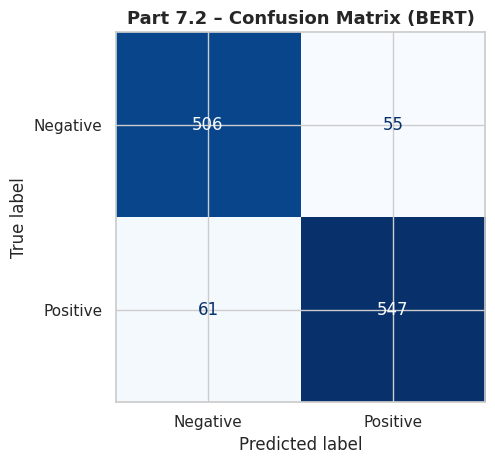

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plot confusion matrix
cm = confusion_matrix(y_test_arr, best_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues", colorbar=False)

plt.title("Part 7.2 – Confusion Matrix (BERT)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**What insights can you gain from studying model misclassifications, and how might this influence future improvements to the model?**

We conduct error analysis using the best-performing model, BERT, to better understand its limitations and identify patterns in misclassified examples.

The model achieves strong performance, but a portion of the test samples are still misclassified. The confusion matrix shows that errors occur in both directions, including false positives and false negatives. This indicates that even a high-performing model like BERT can struggle with certain types of text.

From the examples, we found that the model struggles with contrastive sentence structures, particularly those involving “but.” For example, sentences such as “visually rather stunning, but ultimately…” and “it showcases … but…” contain both positive and negative components. In these cases, the model often focuses on the first clause and fails to fully capture the sentiment shift introduced by the second clause. This suggests difficulty in handling compositional sentiment where meaning depends on sentence structure.

Also, some positive sentences are misclassified as negative, when they are short or contain mixed signals. For example, phrases like “cho’s timing is priceless” or “the acting is good” may lack sufficient context, while sentences such as “exhilarating but blatantly biased” again involve conflicting sentiment cues.

Overall, while BERT significantly outperforms other models, these findings highlight remaining challenges in handling contrastive structures and limited-context inputs. Addressing these issues may require more targeted training data or advanced techniques such as data augmentation or context-aware fine-tuning.



---
# **Part 8 – Optional Challenge Extensions**
---



#8.1 Data Augmentation

In [ ]:
# We choose Synonym Replacement
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import wordnet
import random

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# Get a random synonym for a word

def get_synonym(word):
    synonyms = []

    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word and synonym.isalpha():
                synonyms.append(synonym)

    if len(synonyms) == 0:
        return word

    return random.choice(synonyms)

In [ ]:
# Apply synonym replacement to a sentence

def synonym_swap(sentence, swap_prob=0.15):
    words = sentence.split()
    new_words = []

    for word in words:
        if random.random() < swap_prob:
            new_words.append(get_synonym(word))
        else:
            new_words.append(word)

    return " ".join(new_words)

In [ ]:
# Create augmented training data

aug_train_df = train_df.copy()

aug_train_df["sentence"] = aug_train_df["sentence"].apply(
    lambda x: synonym_swap(str(x))
)

# Combine original + augmented data
combined_train_df = pd.concat([train_df, aug_train_df], axis=0).reset_index(drop=True)

print("Original training size:", len(train_df))
print("Augmented training size:", len(combined_train_df))

Original training size: 5629
Augmented training size: 11258


In [ ]:
# Rebuild TF-IDF features using augmented data

combined_train_df["clean_sentence"] = combined_train_df["sentence"].apply(preprocessor.clean_text)

tfidf_aug = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_aug = tfidf_aug.fit_transform(combined_train_df["clean_sentence"])
X_test_aug  = tfidf_aug.transform(test_df["clean_sentence"])

y_train_aug = combined_train_df["label"].values

In [ ]:
# Train Logistic Regression on augmented data

lr_aug = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    random_state=SEED
)

lr_aug.fit(X_train_aug, y_train_aug)

lr_aug_pred = lr_aug.predict(X_test_aug)
lr_aug_prob = lr_aug.predict_proba(X_test_aug)[:, 1]

aug_results = evaluate(y_test_arr, lr_aug_pred, lr_aug_prob)

In [ ]:
# Compare original vs augmented model

compare_df = pd.DataFrame({
    "Original Logistic Regression": results["Logistic Regression"],
    "Augmented Logistic Regression": aug_results
}).T.round(4)

print(compare_df)

                               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Original Logistic Regression     0.7630     0.7631  0.7895    0.7761   0.8500
Augmented Logistic Regression    0.7579     0.7504  0.8010    0.7749   0.8452


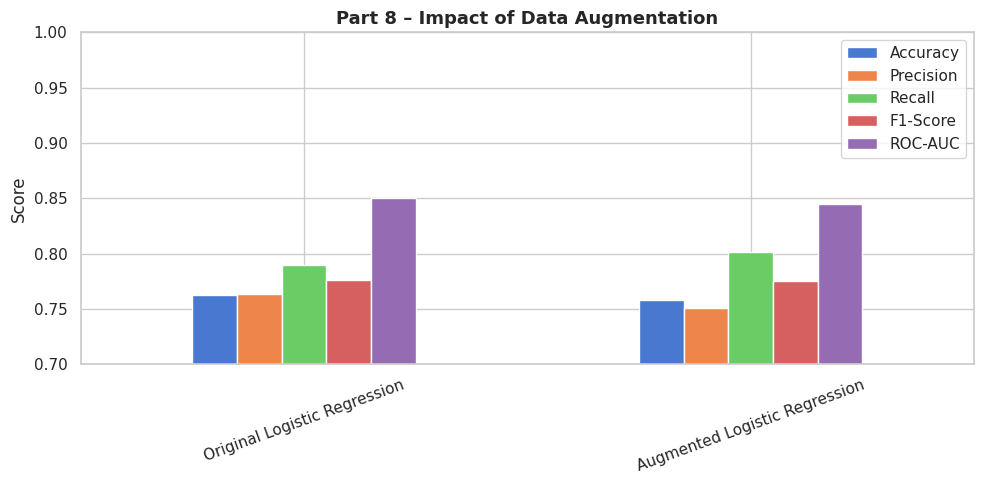

In [ ]:
# Visualization

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

compare_df[metrics].plot(kind="bar", figsize=(10, 5), edgecolor="white")

plt.title("Part 8 – Impact of Data Augmentation", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("fig_augmentation.png", dpi=150)
plt.show()

**How does synonym swapping as text augmentation improve model generalization?**

We use synonym replacement as the augmentation method. The results show that augmentation improves recall, suggesting that the model becomes more sensitive to positive sentiment and better at identifying varied expressions. However, this improvement comes at the cost of reduced precision, indicating an increase in false positives. This shows some limitations of simple word-level augmentation.

#8.2 Sentiment Lexicon

In [ ]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# Initialize VADER sentiment analyzer

sia = SentimentIntensityAnalyzer()

# Create VADER sentiment features
def get_vader_scores(text):
    scores = sia.polarity_scores(str(text))
    return [scores["neg"], scores["neu"], scores["pos"], scores["compound"]]

In [ ]:
# Apply VADER to train and test sets

X_train_vader = np.array(train_df["sentence"].apply(get_vader_scores).tolist())
X_test_vader  = np.array(test_df["sentence"].apply(get_vader_scores).tolist())

print("VADER train shape:", X_train_vader.shape)
print("VADER test shape:", X_test_vader.shape)

VADER train shape: (5629, 4)
VADER test shape: (1169, 4)


In [ ]:
# Combine TF-IDF features with VADER sentiment scores

X_train_tfidf_vader = hstack([X_train_tfidf, X_train_vader])
X_test_tfidf_vader  = hstack([X_test_tfidf, X_test_vader])

print("Combined train shape:", X_train_tfidf_vader.shape)
print("Combined test shape:", X_test_tfidf_vader.shape)

Combined train shape: (5629, 14755)
Combined test shape: (1169, 14755)


In [ ]:
# Train Logistic Regression with TF-IDF + VADER

lr_vader = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    random_state=SEED
)

lr_vader.fit(X_train_tfidf_vader, y_train_arr)

lr_vader_pred = lr_vader.predict(X_test_tfidf_vader)
lr_vader_prob = lr_vader.predict_proba(X_test_tfidf_vader)[:, 1]

vader_results = evaluate(y_test_arr, lr_vader_pred, lr_vader_prob)

In [ ]:
# Compare baseline Logistic Regression with VADER-enhanced Logistic Regression

vader_compare_df = pd.DataFrame({
    "Original LR": results["Logistic Regression"],
    "LR + VADER": vader_results
}).T.round(4)

print(vader_compare_df)

             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Original LR    0.7630     0.7631  0.7895    0.7761    0.850
LR + VADER     0.7665     0.7689  0.7878    0.7782    0.844


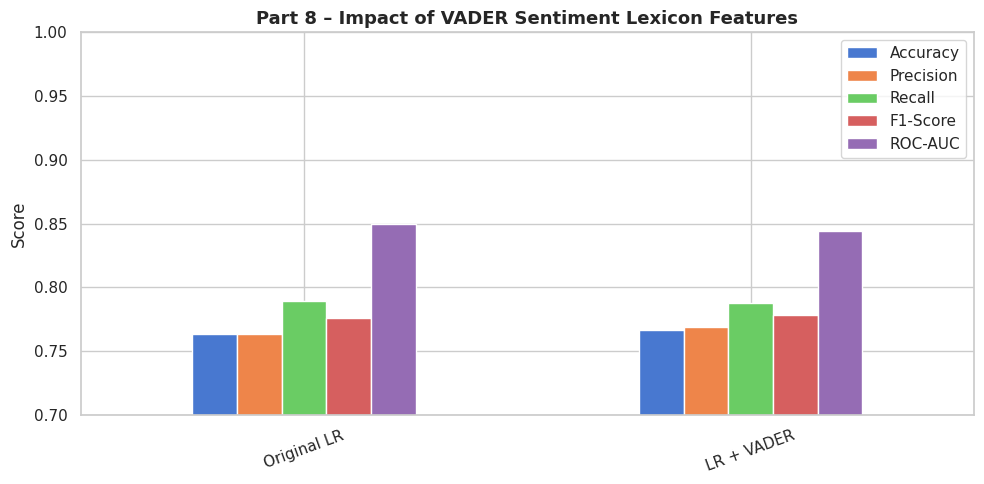

In [ ]:
# Visualize

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

vader_compare_df[metrics].plot(kind="bar", figsize=(10, 5), edgecolor="white")

plt.title("Part 8 – Impact of VADER Sentiment Lexicon Features", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.70, 1.00)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("fig_vader_comparison.png", dpi=150)
plt.show()

**How might integrating sentiment lexicons like VADER improve the sentiment classification model, and what are the challenges of using lexicon-based approaches alongside machine learning models?**

Sentiment lexicons like VADER may provide better sentiment scores for words and phrases, which can be used to enhance sentiment classification models. These lexicons encode prior knowledge about the polarity of common expressions such as “excellent” as positive, “terrible” as negative, allowing models to incorporate explicit sentiment signals beyond learned statistical patterns.

In this case, adding VADER features leads to a modest improvement in model performance. Precision increases from 0.7631 to 0.7689, and F1-score improves slightly from 0.7761 to 0.7782. This suggests that lexicon-based features help the model make more accurate positive predictions by reducing false positives. However, recall decreases slightly, indicating that the model becomes more conservative and may miss some positive samples.

One major challenge of using lexicon-based approaches alongside machine learning models is that lexicons are typically context-independent. They assign fixed sentiment scores to words. This makes it difficult to handle linguistic phenomena such as negation and contrastive structures. For example, phrases like “good but disappointing” cannot be accurately interpreted using word-level sentiment alone.

#8.3 Deploy your best model as a simple REST API using Flask or FastAPI and demo it on a handful of user‐submitted reviews

In [ ]:
!pip install fastapi uvicorn pyngrok

In [ ]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Initialize FastAPI application
app = FastAPI(title="Sentiment Classification API (BERT)")

# Load saved BERT model and tokenizer
model_path = "bert_sentiment_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
bert_model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Set model to evaluation mode
bert_model.eval()


# Define input schema for API request
class ReviewInput(BaseModel):
    review: str


# Show endpoint to verify API is running
@app.get("/")
def home():
    return {"message": "Sentiment API is running."}


# Prediction endpoint for sentiment classification
@app.post("/predict")
def predict_sentiment(input_data: ReviewInput):

    # Extract input text from request
    text = input_data.review

    # Tokenize input text for BERT model
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Perform inference without gradient computation
    with torch.no_grad():
        outputs = bert_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    # Convert prediction to label
    label = "Positive" if pred == 1 else "Negative"

    # Return prediction and probabilities
    return {
        "review": text,
        "prediction": label,
        "negative_probability": round(probs[0][0].item(), 4),
        "positive_probability": round(probs[0][1].item(), 4)
    }

Overwriting app.py


In [ ]:
import uvicorn
import threading

def run_api():
    uvicorn.run("app:app", host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_api)
thread.start()

INFO:     Started server process [2853]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://127.0.0.1:8000

2026-05-01T23:20:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-01T23:20:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-01T23:20:45Z INF +--------------------------------------------------------------------------------------------+
2026-05-01T23:20:45Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-01T23:20:45Z INF |  https://toilet-revenues-heath-describes.trycloudflare

**API Demo and Interpretation**

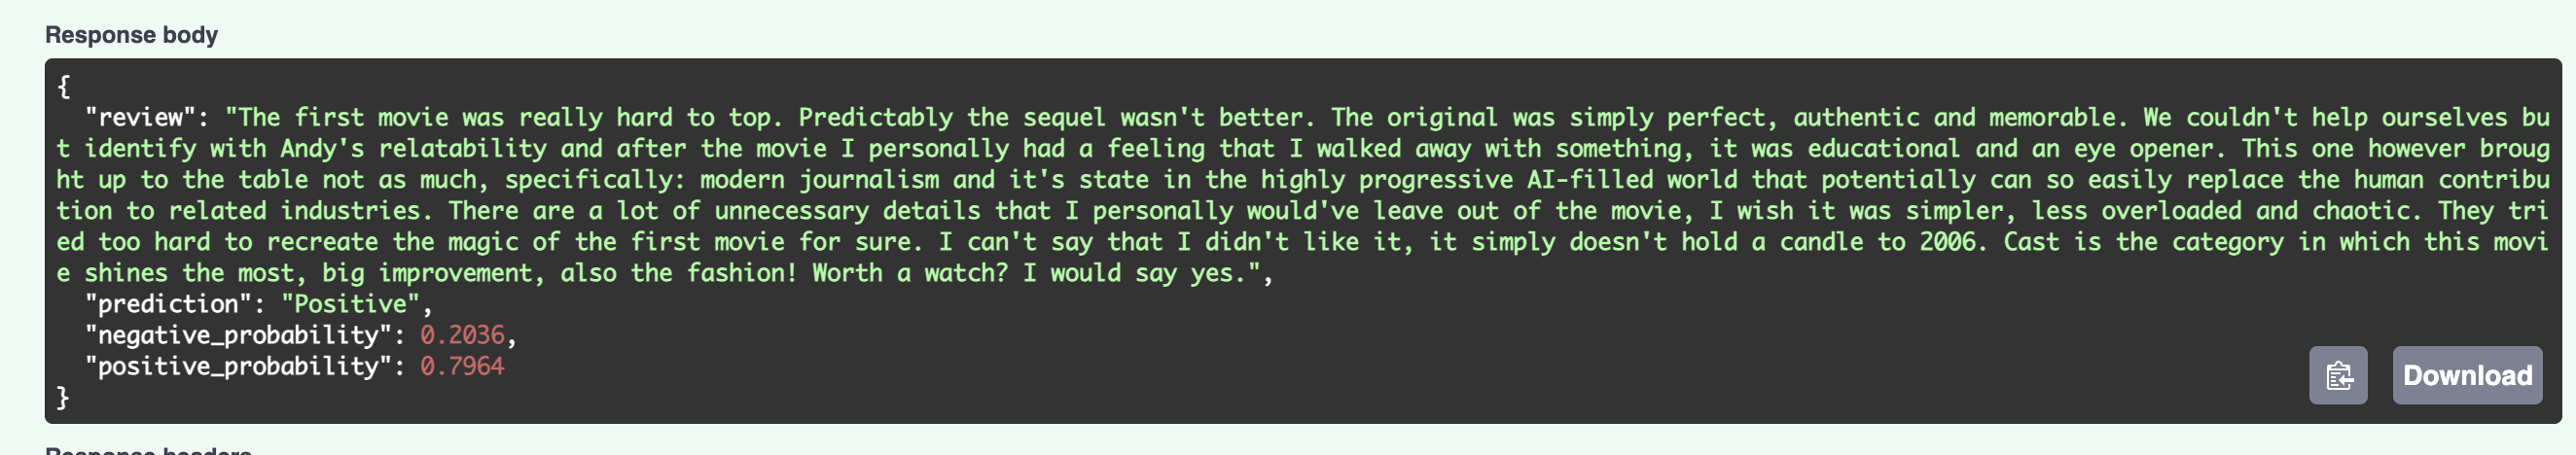
To further evaluate the deployed model, we test it on a real-world movie review collected from IMDb. The reviewer rated the movie 7/10, indicating a generally positive but not strongly enthusiastic opinion.

The model predicts the sentiment as Positive with a relatively high probability (0.7964), which aligns with the overall tone of the review. The text contains multiple positive expressions such as “perfect,” “authentic,” “memorable,” and “worth a watch,” which likely contribute to the model’s prediction.

However, the review also includes several critical and negative statements, such as “wasn't better,” “doesn't hold a candle,” and “too many unnecessary details.” This indicates that the review expresses mixed sentiment, combining both praise and criticism.

This example highlights an important limitation of binary sentiment classification. In real-world scenarios, sentiment often exists on a spectrum rather than as strictly positive or negative.

Overall, this demo shows that the deployed BERT model performs well on general sentiment detection, but may oversimplify nuanced or mixed review.